In [ ]:
import ast
import os
import sys
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import torch
import torch.nn.functional as F
from scipy.io import loadmat
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import cross_val_predict
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.insert(1, "/".join(os.path.abspath("").split("/")[0:-1]))
from importlib import reload

import models

reload(models)

<module 'models' from '/coc/flash12/cli726/_PoissonGradEstim/main/com_poisson/models.py'>

In [ ]:
trial_list = np.arange(0, 3)
method_list = ["score", "GS", "exp-sigmoid", "exp-cubic"]
tau_list = [0.02, 0.05, 0.1, 0.2, 0.5]
seed_list = np.arange(0, 5)
version_list = [f"epoch={epoch}" for epoch in range(19, 300, 20)]

In [ ]:
# tag = "baseline"
tag = "linear"

df_result = []
idx = 0
for (
    trial,
    method,
    tau,
    seed,
    version,
) in product(
    trial_list,
    method_list,
    tau_list,
    seed_list,
    version_list,
):
    results_folder = f"results_{tag}/{trial}_{method}_{tau}_{seed}"
    try:
        df_temp = pd.read_csv(f"{results_folder}/metrics_{version}.csv")
        df_temp["trial"] = trial
        df_temp["method"] = method
        df_temp["tau"] = tau
        df_temp["seed"] = seed
        df_temp["version"] = version
        df_result.append(df_temp)
    except:
        print(
            idx,
            f"{results_folder} not found",
        )
    if version == "epoch=299":
        idx += 1

df_result = pd.concat(df_result, ignore_index=True)

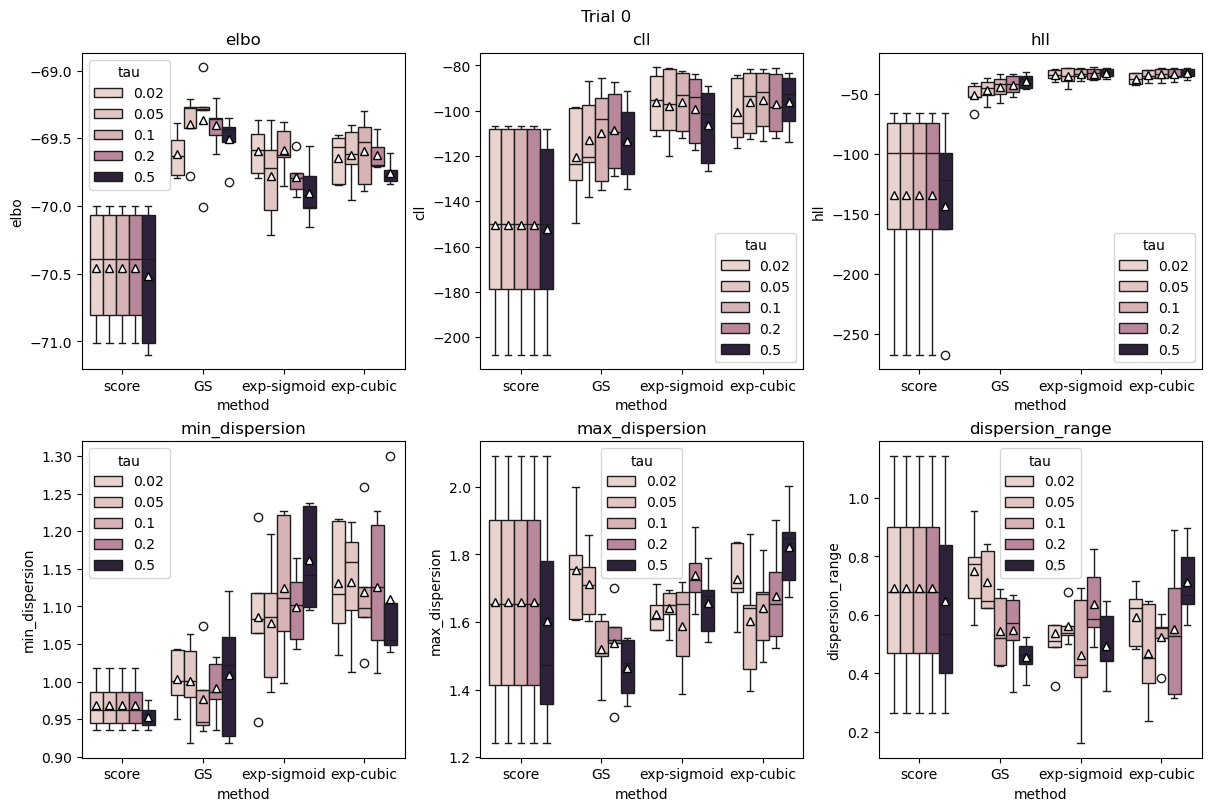

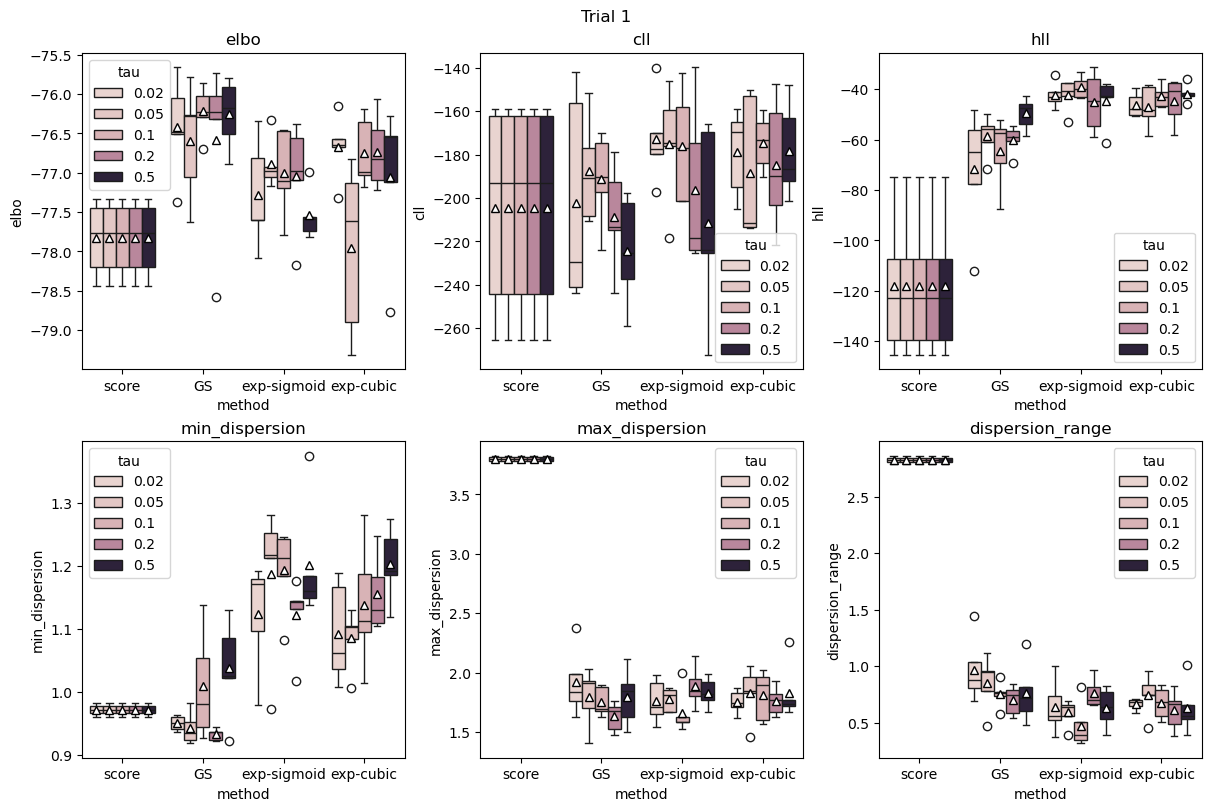

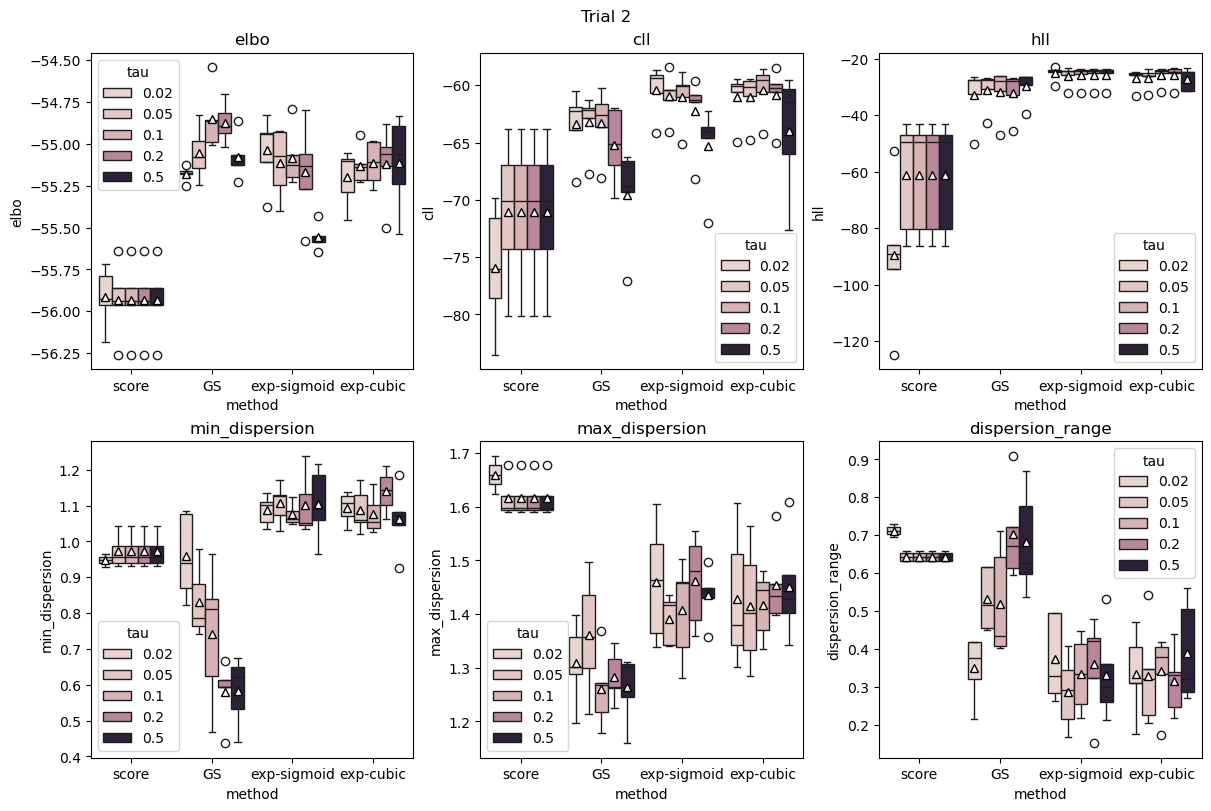

In [16]:
for trial in trial_list:
    fig, axs = plt.subplots(2, 3, figsize=(12, 8), layout="constrained")

    for ax, metric in zip(
        axs.flat,
        [
            "elbo",
            "cll",
            "hll",
            "min_dispersion",
            "max_dispersion",
            "dispersion_range",
            "running_time",
        ],
    ):
        sns.boxplot(
            data=df_result[
                (df_result["version"] == "epoch=299") & (df_result["trial"] == trial)
            ],
            x="method",
            hue="tau",
            y=metric,
            ax=ax,
            showfliers=True,
            showmeans=True,
            meanprops={
                "markerfacecolor": "white",
                "markeredgecolor": "black",
            },
        )
        ax.set_title(metric)
    fig.suptitle(f"Trial {trial}")

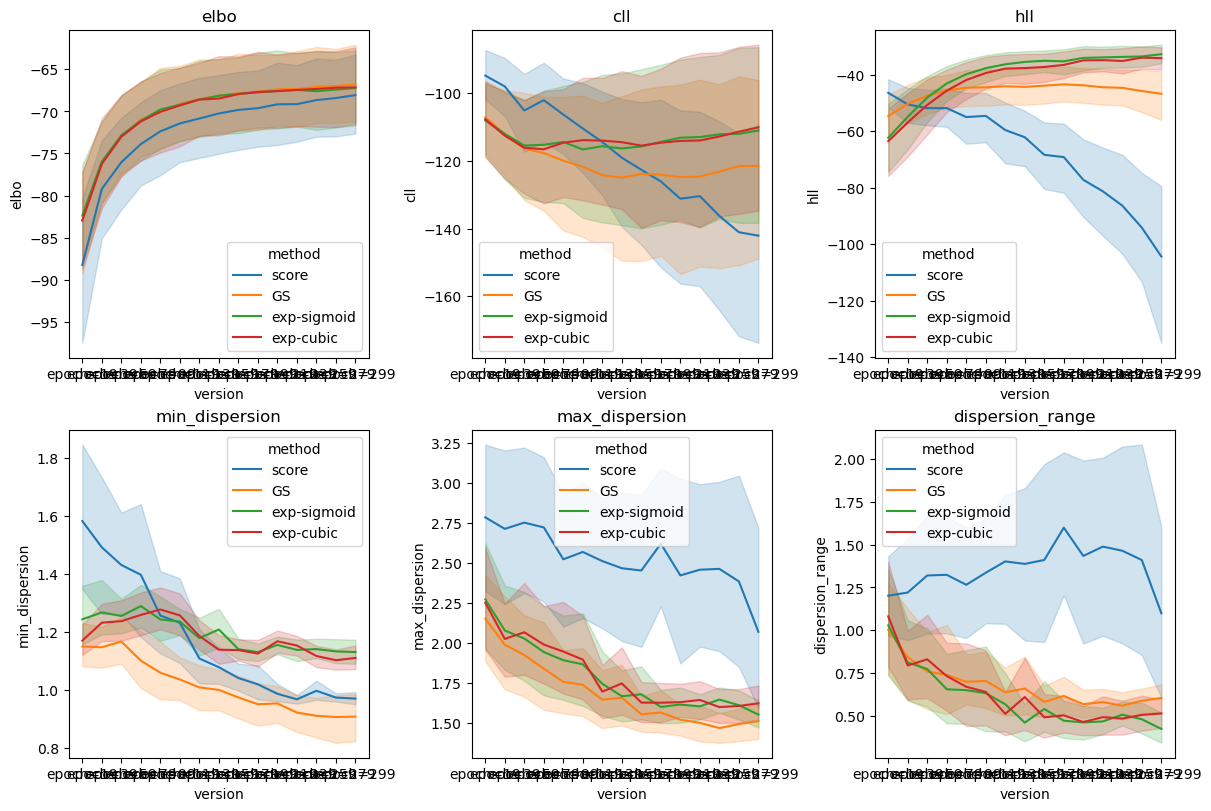

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8), layout="constrained")

for ax, metric in zip(
    axs.flat,
    [
        "elbo",
        "cll",
        "hll",
        "min_dispersion",
        "max_dispersion",
        "dispersion_range",
        "running_time",
    ],
):
    sns.lineplot(
        data=df_result[df_result["tau"] == 0.1],
        x="version",
        hue="method",
        y=metric,
        ax=ax,
    )
    ax.set_title(metric)

In [ ]:
method = method_list[1]
tau = 0.1
seed = 0
version = "epoch=299"

results_folder = f"results_{tag}/{method}_{tau}_{seed}"

df_data = pd.read_pickle(f"data/data.pkl")

In [ ]:
model = models.TwoLayerNetwork(
    dims=(8, 32),
)
lit = models.LitScore.load_from_checkpoint(
    f"{results_folder}/{version}.ckpt",
    model=model,
)
df_data.at[0, "model"]["prior_log_nu"].exp()

tensor([0.6756, 0.5504, 1.3638, 0.6914, 0.7434, 0.4234, 1.2361, 1.5840])

In [ ]:
with torch.inference_mode():
    x_test = df_data.at[0, "x_test"]
    z_test = df_data.at[0, "z_test"]
    encoder_log_rate = lit.model.encoder(x_test)  # (n_test, dims[0])
    encoder_rate = encoder_log_rate.exp()
    print(lit.model.prior_log_nu.exp())

tensor([0.6277, 0.8658, 0.5483, 0.7277, 0.5065, 0.6389, 0.7018, 0.6083])


In [ ]:
np.sort((z_test.mean(dim=0) / z_test.var(dim=0)).numpy())

array([0.57099926, 0.6411457 , 0.74952286, 0.7501723 , 0.8537546 ,
       1.1809721 , 1.2149385 , 1.5238652 ], dtype=float32)

In [ ]:
z_samples = torch.load(
    f"{results_folder}/z_samples_{version}.pt", weights_only=False
)  # (n_samples, dims[0])
nu_empirical = z_samples.mean(dim=0) / z_samples.var(dim=0)
np.sort(nu_empirical.numpy())

array([0.6627001 , 0.7174265 , 0.7435178 , 0.84682244, 0.8766348 ,
       0.88286424, 0.8857376 , 1.0109986 ], dtype=float32)